In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [2]:
def matchSummary(opt):
    for tt in opt._err.targets:
        if tt.line:
           nn=" ".join((tt.line,)+tt.tar)
           rr=tt.action.run()[tt.line][tt.tar]
        else:
           nn=tt.tar
           nn=" ".join(nn)
           rr=tt.action.run()[tt.tar]
        if(type(tt.value)==xt.match.LessThan):
            vv=tt.value.upper
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}') 
        elif(type(tt.value)==xt.match.GreaterThan):
            vv=tt.value.lower
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
        elif(hasattr(tt,'rhs')):
            vv=tt.rhs
            dd=(rr-vv)
            if(tt.ineq_sign=='>'):
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
            else:
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}')   
        else:
            vv=tt.value
            dd=(rr-vv)
            dd=np.abs(dd)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {dd<tt.tol}')

In [3]:
class nonlin_chroma(xd.Action):
    def __init__(self, line):
        self.line = line

    def run(self):
        deg = 4

        delta_values = np.arange(-3e-3, 3e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss4d(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]
        print("qx coeff:", qx_coeff)

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]
        print("qy coeff:", qy_coeff)

        return {'qx0': qx_coeff[4], 'qy0': qy_coeff[4], 
                'qx1': qx_coeff[3], 'qy1': qy_coeff[3], 
                'qx2': qx_coeff[2], 'qy2': qy_coeff[2], 
                'qx3': qx_coeff[1], 'qy3': qy_coeff[1], 
                'qx4': qx_coeff[0], 'qy4': qy_coeff[0], 
                # 'qx5': qx_coeff[2], 'qy5': qy_coeff[2], 
                # 'qx6': qx_coeff[1], 'qy6': qy_coeff[1], 
                # 'qx7': qx_coeff[0], 'qy7': qy_coeff[0], 
               }

In [150]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

# Load fitting

In [5]:
line = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
tt = line.get_table()

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.extend_knl_ksl(order=9, element_names=list(mba)+list(mbb)+list(qf)+list(qd))
#Creating knobs for the non-linear chromaticity fit
env['b3_mba'] = 0
env['b3_mbb'] = 0
env['b4_qd'] = 0
env['b4_qf'] = 0
env['b5_mba'] = 0
env['b5_mbb'] = 0
env['b6_qd'] = 0
env['b6_qf'] = 0
# env['b7_mba'] = 0
# env['b7_mbb'] = 0
# env['b8_qd'] = 0
# env['b8_qf'] = 0
# env['b9_mba'] = 0
# env['b9_mbb'] = 0
#Defining deferred expressions for each dipole and quadrupole
#Dipoles get b3,b5
#Quadrupoles get b4,b6

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.vars["qph_setvalue"] = 0.0
# env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl[2] = 'b3_mba'
    env[nn].knl[4] = 'b5_mba'
for nn in mbb:
    env[nn].knl[2] = 'b3_mbb'
    env[nn].knl[4] = 'b5_mbb'
for nn in qf:
    env[nn].knl[3] = 'b4_qf'
    env[nn].knl[5] = 'b6_qf'
for nn in qd:
    env[nn].knl[3] = 'b4_qd'
    env[nn].knl[5] = 'b6_qd'


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


# Test

In [6]:
# import json
# from pathlib import Path

# path = Path("/private/tmp/naff_h0_polynomial_fit_from_points_deg4_to_deg7.json")
# data = json.loads(path.read_text())

# fits_by_degree = {entry["degree"]: entry for entry in data["fits"]}

# # qx_coeff_deg4 = fits_by_degree[4]["qx_coefficients"]
# # qy_coeff_deg4 = fits_by_degree[4]["qy_coefficients"]
# qx_coeff = fits_by_degree[7]["qx_coefficients"]
# qy_coeff = fits_by_degree[7]["qy_coefficients"]

with open("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit/tune_poly_coefficients.json") as f:
      coeffs = json.load(f)

qx_coeff = np.array(coeffs["Qx_kickH"]["poly4"]["coefficients_high_to_low"])
qy_coeff = np.array(coeffs["Qy_kickV"]["poly4"]["coefficients_high_to_low"])

In [7]:
qx_coeff

array([ 3.48905585e+07, -6.99178244e+04, -3.78713127e+02,  1.27858235e+00,
        1.35359791e-01])

In [8]:
qx0 = qx_coeff[4] + 20
qx1 = qx_coeff[3]
qx2 = qx_coeff[2]
qx3 = qx_coeff[1]
qx4 = qx_coeff[0]

qy0 = qy_coeff[4] + 20
qy1 = qy_coeff[3]
qy2 = qy_coeff[2]
qy3 = qy_coeff[1]
qy4 = qy_coeff[0]

In [9]:
print(qx0, qx1, qx2, qx3, qx4)
print(qy0, qy1, qy2, qy3, qy4)

20.13535979106999 1.2785823482553347 -378.7131272614749 -69917.82435776772 34890558.50411756
20.179123667752542 1.3041185206793962 -771.4319043465492 68241.03673791417 17890696.198098958


In [10]:
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 11.36                             
Matching: model call n. 15 penalty = 6.1372e-06              
Optimize - end penalty:  6.13721e-06                            


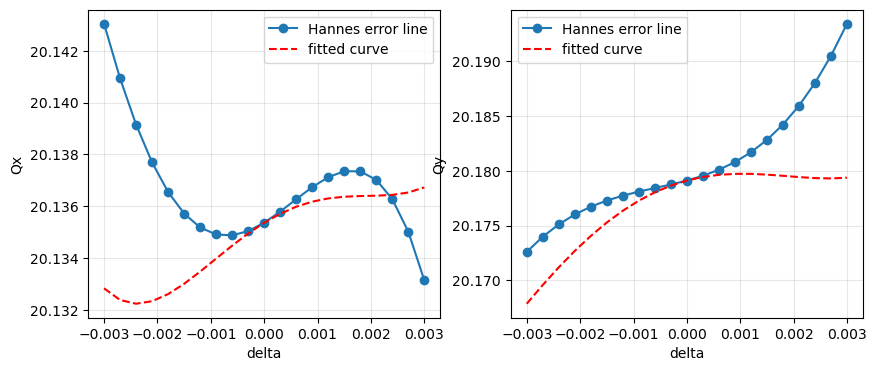

In [11]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
# d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
# axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
# axes[0].set_ylabel("Qx")
# axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
# axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

# Optimisation test

In [12]:
line.vars["qph_setvalue"] = 0.154
line.vars["qpv_setvalue"] = 0.3

In [13]:
act_chroma = nonlin_chroma(line)

## Optimising tune

In [14]:
#Measured tunes at delta=0
opt_tune = line.match(
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(qx=qx0, qy=qy0, tol=1e-10),
    ])

                                             
Optimize - start penalty: 0.1878                            
Matching: model call n. 11 penalty = 4.8027e-10              
Optimize - end penalty:  4.80273e-10                            


In [15]:
print("Quadrupole strengths needed to recover measured tunes:")
print("kqf =", line.vars["kqf"]._get_value())
print("kqd =", line.vars["kqd"]._get_value())

Quadrupole strengths needed to recover measured tunes:
kqf = 0.011586679288589604
kqd = -0.01158670849506777


In [16]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
# print("Q5:")
# print("targets  :", qx5, qy5)
# print("obtained :", test_fit["qx5"], test_fit["qy5"])
# print("Q6:")
# print("targets  :", qx6, qy6)
# print("obtained :", test_fit["qx6"], test_fit["qy6"])
# print("Q7:")
# print("targets  :", qx7, qy7)
# print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [ 3.98002019e+03  3.00981590e+02 -2.50713747e+01  3.09295925e+00
  2.01353648e+01]
qy coeff: [-1.23022743e+04  1.37611090e+03 -1.24813124e+02  5.93611503e+00
  2.01791315e+01]
Q0:
targets  : 20.13535979106999 20.179123667752542
obtained : 20.135364767530298 20.179131503321255
Q1:
targets  : 1.2785823482553347 1.3041185206793962
obtained : 3.092959254099627 5.936115029650639
Q2:
targets  : -378.7131272614749 -771.4319043465492
obtained : -25.071374735865245 -124.81312377209673
Q3:
targets  : -69917.82435776772 68241.03673791417
obtained : 300.9815899697108 1376.1109017912725
Q4:
targets  : 34890558.50411756 17890696.198098958
obtained : 3980.020188349359 -12302.27425093859


In [14]:
# delta_grid = np.linspace(-3e-3, 3e-3, 21)
# d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

# fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
# axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
# axes[0].set_ylabel("Qx")
# axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
# axes[1].set_ylabel("Qy")

# axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
# axes[0].set_ylabel("Qx")
# axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
# axes[1].set_ylabel("Qy")

# axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
# axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
# for ax in axes:
#     ax.set_xlabel("delta")
#     ax.grid(True, alpha=0.3)

# axes[0].legend()
# axes[1].legend()

## Optimising q1

In [17]:
opt_q1 = line.match(
    vary=[
        xt.VaryList(['b3_mba', 'b3_mbb'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-7),
    ])

                                             
Optimize - start penalty: 4.975                             
Matching: model call n. 32 penalty = 6.4566e-09              
Optimize - end penalty:  6.45656e-09                            


In [18]:
print("Sextupole errors on main dipoles needed to recover first order chromaticity:")
print("b3_mba =", line.vars["b3_mba"]._get_value())
print("b3_mbb =", line.vars["b3_mbb"]._get_value())

Sextupole errors on main dipoles needed to recover first order chromaticity:
b3_mba = -0.0007785494275076842
b3_mbb = 0.0012130207893885998


In [21]:
qx_coeff

array([ 3.48905585e+07, -6.99178244e+04, -3.78713127e+02,  1.27858235e+00,
        1.35359791e-01])

In [19]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
# print("Q5:")
# print("targets  :", qx5, qy5)
# print("obtained :", test_fit["qx5"], test_fit["qy5"])
# print("Q6:")
# print("targets  :", qx6, qy6)
# print("obtained :", test_fit["qx6"], test_fit["qy6"])
# print("Q7:")
# print("targets  :", qx7, qy7)
# print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [ 4.24187615e+03  2.71613816e+02 -1.97917796e+01  1.27851573e+00
  2.01353636e+01]
qy coeff: [-7.00725893e+03  1.01122318e+03 -1.00603218e+02  1.30384804e+00
  2.01791281e+01]
Q0:
targets  : 20.13535979106999 20.179123667752542
obtained : 20.13536364111543 20.179128139978953
Q1:
targets  : 1.2785823482553347 1.3041185206793962
obtained : 1.2785157282817252 1.3038480409077453
Q2:
targets  : -378.7131272614749 -771.4319043465492
obtained : -19.79177962735573 -100.60321754141118
Q3:
targets  : -69917.82435776772 68241.03673791417
obtained : 271.6138160057135 1011.2231844397841
Q4:
targets  : 34890558.50411756 17890696.198098958
obtained : 4241.876145793931 -7007.258930521276


In [18]:
# delta_grid = np.linspace(-3e-3, 3e-3, 21)
# d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

# fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
# axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
# axes[0].set_ylabel("Qx")
# axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
# axes[1].set_ylabel("Qy")

# axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
# axes[0].set_ylabel("Qx")
# axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
# axes[1].set_ylabel("Qy")

# axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
# axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
# for ax in axes:
#     ax.set_xlabel("delta")
#     ax.grid(True, alpha=0.3)

# axes[0].legend()
# axes[1].legend()

In [20]:
tw = line.twiss()

## Set initial guesses for higher order errors

In [ ]:
# This does not always work
line.vars["b4_qd"] = 1930.0599410102166
line.vars["b4_qf"] = 747.9243668498927

line.vars["b5_mba"] = -147176.6425580749
line.vars["b5_mbb"] = 846719.6052980867

line.vars["b6_qd"] = 2040.0
line.vars["b6_qf"] = -870.0

# line.vars['b7_mba'] = -147176.6425580749
# line.vars['b7_mbb'] = 846719.6052980867

# line.vars['b8_qd'] = 13329213394.776815
# line.vars['b8_qf'] = -155992507663.70065

# line.vars['b9_mba'] = -147176.6425580749
# line.vars['b9_mbb'] = 846719.6052980867

## Optimising q2

In [23]:
qx2

np.float64(-378.7131272614749)

In [22]:
opt_q2 = line.match(
    vary=[
        xt.VaryList(['b4_qd', 'b4_qf'], step=1e-7), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx2', value=qx2, tol=(np.abs(qx2) * 0.01), tag='qx2'),
        xt.Target(action=act_chroma, tar='qy2', value=qy2, tol=(np.abs(qy2) * 0.01), tag='qy2'),
    ])

qx coeff: [ 4.24187615e+03  2.71613816e+02 -1.97917796e+01  1.27851573e+00
  2.01353636e+01]
qy coeff: [-7.00725893e+03  1.01122318e+03 -1.00603218e+02  1.30384804e+00
  2.01791281e+01]
qx coeff: [ 4.24187615e+03  2.71613816e+02 -1.97917796e+01  1.27851573e+00
  2.01353636e+01]
qy coeff: [-7.00725893e+03  1.01122318e+03 -1.00603218e+02  1.30384804e+00
  2.01791281e+01]
                                             
qx coeff: [ 4.24187615e+03  2.71613816e+02 -1.97917796e+01  1.27851573e+00
  2.01353636e+01]
qy coeff: [-7.00725893e+03  1.01122318e+03 -1.00603218e+02  1.30384804e+00
  2.01791281e+01]
Optimize - start penalty: 760.8                             
qx coeff: [ 4.24187615e+03  2.71613816e+02 -1.97917796e+01  1.27851573e+00
  2.01353636e+01]
qy coeff: [-7.00725893e+03  1.01122318e+03 -1.00603218e+02  1.30384804e+00
  2.01791281e+01]
qx coeff: [ 4.23999903e+03  2.71606299e+02 -1.97916669e+01  1.27851576e+00
  2.01353636e+01]
qy coeff: [-7.00729141e+03  1.01122384e+03 -1.00603563e+

In [23]:
print("Octupole errors on main quadrupoles needed to recover second order chromaticity:")
print("b4_qf =", line.vars["b4_qf"]._get_value())
print("b4_qd =", line.vars["b4_qd"]._get_value())

Octupole errors on main quadrupoles needed to recover second order chromaticity:
b4_qf = -0.05594712451469475
b4_qd = 0.24598412796712704


In [24]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
# print("Q5:")
# print("targets  :", qx5, qy5)
# print("obtained :", test_fit["qx5"], test_fit["qy5"])
# print("Q6:")
# print("targets  :", qx6, qy6)
# print("obtained :", test_fit["qx6"], test_fit["qy6"])
# print("Q7:")
# print("targets  :", qx7, qy7)
# print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [-5.59983300e+04  1.82167520e+03 -3.79724957e+02  1.27851324e+00
  2.01353776e+01]
qy coeff: [-1.71467979e+05  5.01534157e+03 -7.71376963e+02  1.30907439e+00
  2.01791733e+01]
Q0:
targets  : 20.13535979106999 20.179123667752542
obtained : 20.13537764771787 20.179173323596807
Q1:
targets  : 1.2785823482553347 1.3041185206793962
obtained : 1.2785132426841188 1.309074387834364
Q2:
targets  : -378.7131272614749 -771.4319043465492
obtained : -379.72495698098516 -771.3769628269249
Q3:
targets  : -69917.82435776772 68241.03673791417
obtained : 1821.6752023534684 5015.341567712524
Q4:
targets  : 34890558.50411756 17890696.198098958
obtained : -55998.32997560213 -171467.97887508976


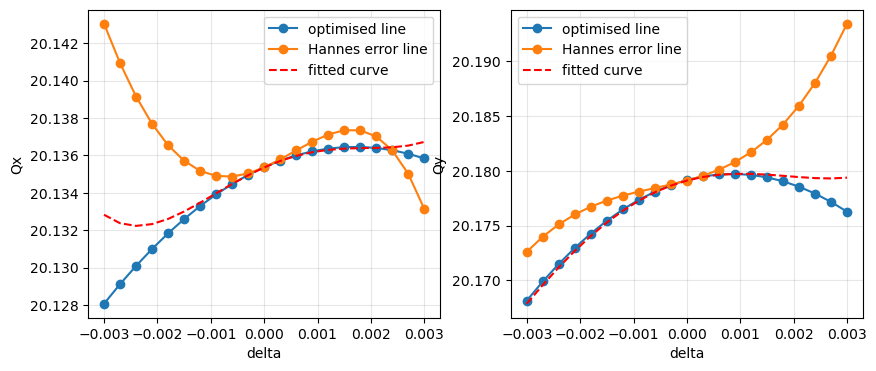

In [26]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4 , 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4 , 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising q3

In [27]:
opt_q3 = line.match(
    vary=[
        xt.VaryList(['b5_mba', 'b5_mbb'], step=1e-4), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx3', value=qx3, tol=(np.abs(qx3) * 0.0001), tag='qx3'),
        xt.Target(action=act_chroma, tar='qy3', value=qy3, tol=(np.abs(qy3) * 0.0001), tag='qy3'),
])

qx coeff: [-5.59983300e+04  1.82167520e+03 -3.79724957e+02  1.27851324e+00
  2.01353776e+01]
qy coeff: [-1.71467979e+05  5.01534157e+03 -7.71376963e+02  1.30907439e+00
  2.01791733e+01]
qx coeff: [-5.59983300e+04  1.82167520e+03 -3.79724957e+02  1.27851324e+00
  2.01353776e+01]
qy coeff: [-1.71467979e+05  5.01534157e+03 -7.71376963e+02  1.30907439e+00
  2.01791733e+01]
                                             
qx coeff: [-5.59983300e+04  1.82167520e+03 -3.79724957e+02  1.27851324e+00
  2.01353776e+01]
qy coeff: [-1.71467979e+05  5.01534157e+03 -7.71376963e+02  1.30907439e+00
  2.01791733e+01]
Optimize - start penalty: 9.562e+04                         
qx coeff: [-5.59983300e+04  1.82167520e+03 -3.79724957e+02  1.27851324e+00
  2.01353776e+01]
qy coeff: [-1.71467979e+05  5.01534157e+03 -7.71376963e+02  1.30907439e+00
  2.01791733e+01]
qx coeff: [-5.60288585e+04  1.82625550e+03 -3.79724951e+02  1.27851322e+00
  2.01353776e+01]
qy coeff: [-1.71474654e+05  5.01287702e+03 -7.71376961e+

In [28]:
print("Decapole errors on main dipoles needed to recover third order chromaticity:")
print("b5_mba =", line.vars["b5_mba"]._get_value())
print("b5_mbb =", line.vars["b5_mbb"]._get_value())

Decapole errors on main dipoles needed to recover third order chromaticity:
b5_mba = -1.0657956658812537
b5_mbb = -1.8408132106887778


In [29]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
# print("Q5:")
# print("targets  :", qx5, qy5)
# print("obtained :", test_fit["qx5"], test_fit["qy5"])
# print("Q6:")
# print("targets  :", qx6, qy6)
# print("obtained :", test_fit["qx6"], test_fit["qy6"])
# print("Q7:")
# print("targets  :", qx7, qy7)
# print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [ 4.48054924e+05 -6.99177613e+04 -3.79890484e+02  1.27900782e+00
  2.01353778e+01]
qy coeff: [-1.66165228e+05  6.82410368e+04 -7.71393167e+02  1.30899227e+00
  2.01791733e+01]
Q0:
targets  : 20.13535979106999 20.179123667752542
obtained : 20.13537775578061 20.179173324345648
Q1:
targets  : 1.2785823482553347 1.3041185206793962
obtained : 1.279007818211738 1.3089922703625716
Q2:
targets  : -378.7131272614749 -771.4319043465492
obtained : -379.8904838287271 -771.3931673925541
Q3:
targets  : -69917.82435776772 68241.03673791417
obtained : -69917.76131146672 68241.0368420719
Q4:
targets  : 34890558.50411756 17890696.198098958
obtained : 448054.92443327204 -166165.22839179574


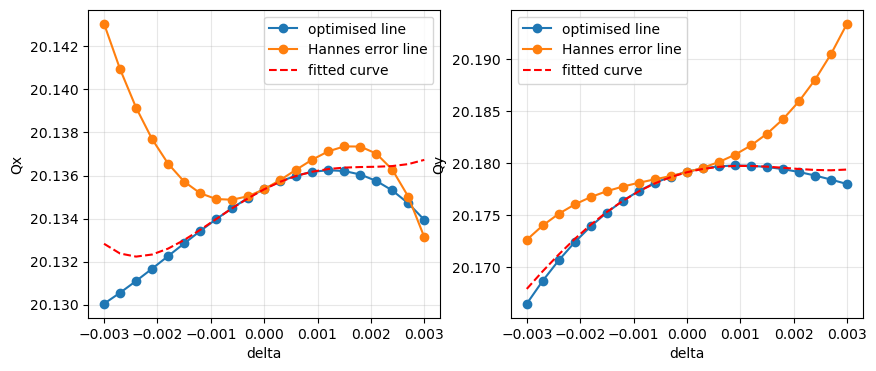

In [30]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising q4

In [32]:
opt_q4 = line.match(
    vary=[
        xt.VaryList(['b6_qd', 'b6_qf'], step=1e-1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx4', value=qx4, tol=(np.abs(qx4) * 0.0001), tag='qx4'),
        xt.Target(action=act_chroma, tar='qy4', value=qy4, tol=(np.abs(qy4) * 0.0001), tag='qy4'),
    ])

qx coeff: [ 4.48054924e+05 -6.99177613e+04 -3.79890484e+02  1.27900782e+00
  2.01353778e+01]
qy coeff: [-1.66165228e+05  6.82410368e+04 -7.71393167e+02  1.30899227e+00
  2.01791733e+01]
qx coeff: [ 4.48054924e+05 -6.99177613e+04 -3.79890484e+02  1.27900782e+00
  2.01353778e+01]
qy coeff: [-1.66165228e+05  6.82410368e+04 -7.71393167e+02  1.30899227e+00
  2.01791733e+01]
                                             
qx coeff: [ 4.48054924e+05 -6.99177613e+04 -3.79890484e+02  1.27900782e+00
  2.01353778e+01]
qy coeff: [-1.66165228e+05  6.82410368e+04 -7.71393167e+02  1.30899227e+00
  2.01791733e+01]
Optimize - start penalty: 3.889e+07                         
qx coeff: [ 4.48054924e+05 -6.99177613e+04 -3.79890484e+02  1.27900782e+00
  2.01353778e+01]
qy coeff: [-1.66165228e+05  6.82410368e+04 -7.71393167e+02  1.30899227e+00
  2.01791733e+01]
qx coeff: [ 4.48176668e+05 -6.99177756e+04 -3.79890480e+02  1.27900785e+00
  2.01353778e+01]
qy coeff: [-1.66587366e+05  6.82410515e+04 -7.71393148e+

In [33]:
print("Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:")
print("b6_qf =", line.vars["b6_qf"]._get_value())
print("b6_qd =", line.vars["b6_qd"]._get_value())

Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:
b6_qf = 1023.2580116867604
b6_qd = -7241.383924419397


In [34]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
# print("Q5:")
# print("targets  :", qx5, qy5)
# print("obtained :", test_fit["qx5"], test_fit["qy5"])
# print("Q6:")
# print("targets  :", qx6, qy6)
# print("obtained :", test_fit["qx6"], test_fit["qy6"])
# print("Q7:")
# print("targets  :", qx7, qy7)
# print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [ 3.48915855e+07 -7.15082466e+04 -3.81626158e+02  1.28176775e+00
  2.01353833e+01]
qy coeff: [ 1.78906941e+07  6.64434388e+04 -7.73322609e+02  1.31187253e+00
  2.01791803e+01]
Q0:
targets  : 20.13535979106999 20.179123667752542
obtained : 20.135383253312227 20.179180316002526
Q1:
targets  : 1.2785823482553347 1.3041185206793962
obtained : 1.2817677498431272 1.3118725288550486
Q2:
targets  : -378.7131272614749 -771.4319043465492
obtained : -381.6261575448809 -773.3226090807326
Q3:
targets  : -69917.82435776772 68241.03673791417
obtained : -71508.2466010721 66443.43881397998
Q4:
targets  : 34890558.50411756 17890696.198098958
obtained : 34891585.50609951 17890694.072304696


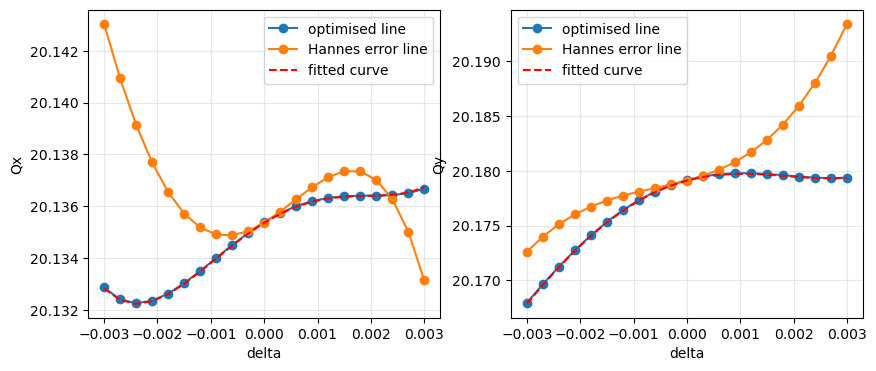

In [35]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

In [46]:
line.to_json("sps_with_aperture_inj_q20_beam_sagitta4_optimised.json")

## Optimising q5

In [32]:
opt_q5 = line.match(
    vary=[
        xt.VaryList(['b7_mba', 'b7_mbb'], step=1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx5', value=qx5, tol=(np.abs(qx5) * 0.001), tag='qx5'),
        xt.Target(action=act_chroma, tar='qy5', value=qy5, tol=(np.abs(qy5) * 0.001), tag='qy5'),
    ])

qx coeff: [-4.08469793e+07  5.59209010e+05 -7.44452508e+02  7.06613986e-01
  2.01356861e+01]
qy coeff: [ 2.65013778e+06 -4.64890465e+05 -1.24082588e+03  1.94471237e+00
  2.01792427e+01]
qx coeff: [-4.08469793e+07  5.59209010e+05 -7.44452508e+02  7.06613986e-01
  2.01356861e+01]
qy coeff: [ 2.65013778e+06 -4.64890465e+05 -1.24082588e+03  1.94471237e+00
  2.01792427e+01]
                                             
qx coeff: [-4.08469793e+07  5.59209010e+05 -7.44452508e+02  7.06613986e-01
  2.01356861e+01]
qy coeff: [ 2.65013778e+06 -4.64890465e+05 -1.24082588e+03  1.94471237e+00
  2.01792427e+01]
Optimize - start penalty: 1.993e+11                         
qx coeff: [-4.08469793e+07  5.59209010e+05 -7.44452508e+02  7.06613986e-01
  2.01356861e+01]
qy coeff: [ 2.65013778e+06 -4.64890465e+05 -1.24082588e+03  1.94471237e+00
  2.01792427e+01]
qx coeff: [-4.08469793e+07  5.59209010e+05 -7.44452508e+02  7.06613986e-01
  2.01356861e+01]
qy coeff: [ 2.65013778e+06 -4.64890465e+05 -1.24082588e+

RuntimeError: Could not find point within tolerance.

In [ ]:
print("Tetradecapole errors on main dipoles needed to recover fifth order chromaticity:")
print("b7 =", line.vars["b7_mba"]._get_value())
print("b7 =", line.vars["b7_mbb"]._get_value())

In [ ]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [-3.44868645e+07 -9.85162637e+04 -1.00367191e+03  1.35392252e+00
  2.01355851e+01]
qy coeff: [2.56336652e+06 3.81445103e+04 8.28550429e+02 1.41136875e+00
 2.01789301e+01]
Q0:
targets  : 20.135535824977346 20.178981746444332
obtained : 20.135585067232697 20.17893009590717
Q1:
targets  : 1.3522157005522508 1.4191477402189625
obtained : 1.3539225233158372 1.4113687478136654
Q2:
targets  : -501.5724668554806 -886.8119292050295
obtained : -1003.6719102460187 828.5504294342184
Q3:
targets  : -98516.12238238202 38144.506688347676
obtained : -98516.26370553652 38144.51034743913
Q4:
targets  : 40325329.202421896 43524952.068756945
obtained : -34486864.4530695 2563366.524707647


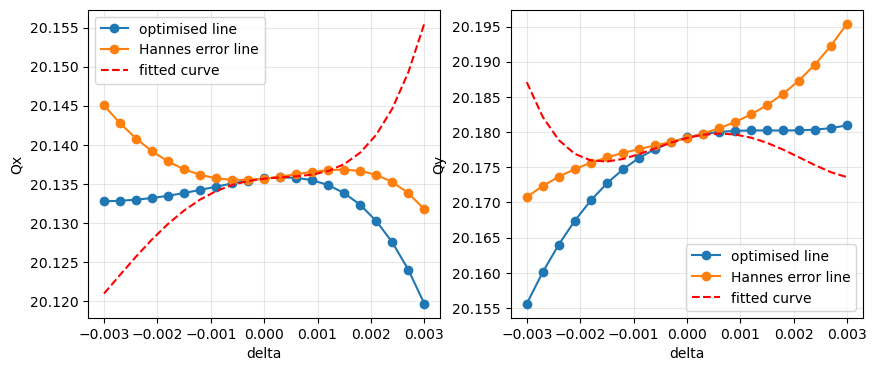

In [ ]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4 + qx5*delta_grid**5 + qx6*delta_grid**6 + qx7*delta_grid**7, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4 + qy5*delta_grid**5 + qy6*delta_grid**6 + qy7*delta_grid**7, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising q6

In [ ]:
opt_q6 = line.match(solve=False,
        vary=[
            xt.VaryList(['b8_qd', 'b8_qf'], step=10), 
        ],
        targets=[
            xt.Target(action=act_chroma, tar='qx6', value=qx6, tol=(np.abs(qx6) * 0.001), tag='qx6'),
            xt.Target(action=act_chroma, tar='qy6', value=qy6, tol=(np.abs(qy6) * 0.001), tag='qy6'),
        ])

In [ ]:
print("Hexadecapole errors on main quadrupoles needed to recover sixth order chromaticity:")
print("b8_qd =", line.vars["b8_qd"]._get_value())
print("b8_qf =", line.vars["b8_qf"]._get_value())

In [ ]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [-3.44868645e+07 -9.85162637e+04 -1.00367191e+03  1.35392252e+00
  2.01355851e+01]
qy coeff: [2.56336652e+06 3.81445103e+04 8.28550429e+02 1.41136875e+00
 2.01789301e+01]
Q0:
targets  : 20.135535824977346 20.178981746444332
obtained : 20.135585067232697 20.17893009590717
Q1:
targets  : 1.3522157005522508 1.4191477402189625
obtained : 1.3539225233158372 1.4113687478136654
Q2:
targets  : -501.5724668554806 -886.8119292050295
obtained : -1003.6719102460187 828.5504294342184
Q3:
targets  : -98516.12238238202 38144.506688347676
obtained : -98516.26370553652 38144.51034743913
Q4:
targets  : 40325329.202421896 43524952.068756945
obtained : -34486864.4530695 2563366.524707647


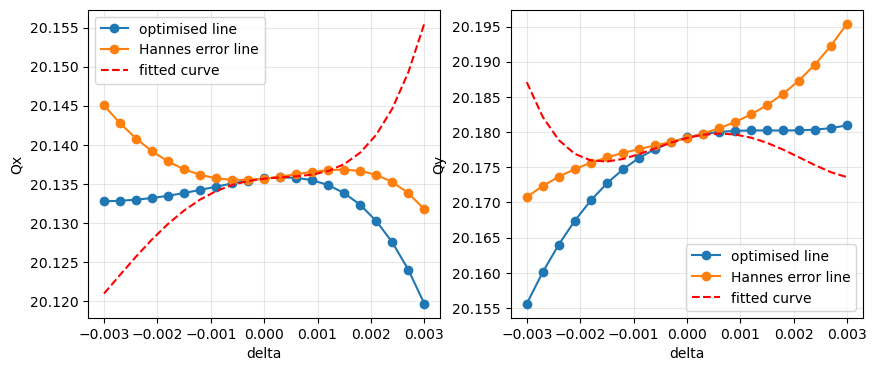

In [ ]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4 + qx5*delta_grid**5 + qx6*delta_grid**6 + qx7*delta_grid**7, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4 + qy5*delta_grid**5 + qy6*delta_grid**6 + qy7*delta_grid**7, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising q7

In [ ]:
opt_q7 = line.match(
    vary=[
        xt.VaryList(['b9_mba', 'b9_mbb'], step=1000), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx7', value=qx7, tol=(np.abs(qx7) * 0.001), tag='qx7'),
        xt.Target(action=act_chroma, tar='qy7', value=qy7, tol=(np.abs(qy7) * 0.001), tag='qy7'),
    ])

In [ ]:
print("Octadecapole errors on main quadrupoles needed to recover seventh order chromaticity:")
print("b9_mba =", line.vars["b9_mba"]._get_value())
print("b9_mbb =", line.vars["b9_mbb"]._get_value())

In [ ]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

qx coeff: [-3.44868645e+07 -9.85162637e+04 -1.00367191e+03  1.35392252e+00
  2.01355851e+01]
qy coeff: [2.56336652e+06 3.81445103e+04 8.28550429e+02 1.41136875e+00
 2.01789301e+01]
Q0:
targets  : 20.135535824977346 20.178981746444332
obtained : 20.135585067232697 20.17893009590717
Q1:
targets  : 1.3522157005522508 1.4191477402189625
obtained : 1.3539225233158372 1.4113687478136654
Q2:
targets  : -501.5724668554806 -886.8119292050295
obtained : -1003.6719102460187 828.5504294342184
Q3:
targets  : -98516.12238238202 38144.506688347676
obtained : -98516.26370553652 38144.51034743913
Q4:
targets  : 40325329.202421896 43524952.068756945
obtained : -34486864.4530695 2563366.524707647


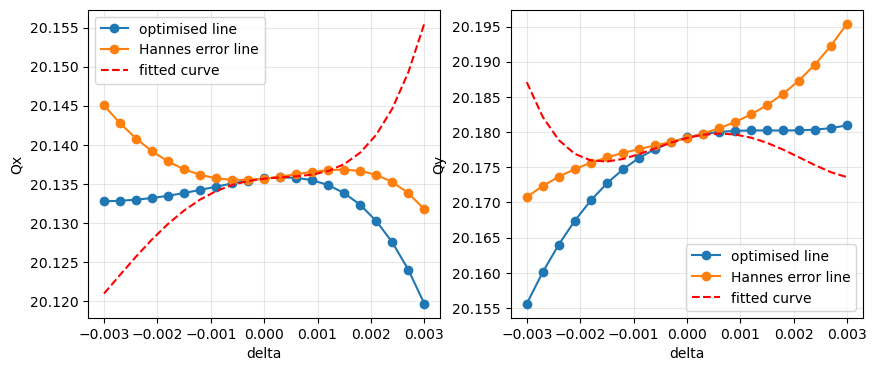

In [ ]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4 + qx5*delta_grid**5 + qx6*delta_grid**6 + qx7*delta_grid**7, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4 + qy5*delta_grid**5 + qy6*delta_grid**6 + qy7*delta_grid**7, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

In [ ]:
# line.to_json("sps_with_aperture_inj_q20_beam_sagitta4_fit_errors.json")

In [36]:
line3 = xt.Line.from_json("sps_with_aperture_inj_q20_beam_sagitta4.json")

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [37]:
line3 = xt.Line.from_json("sps_with_aperture_inj_q20_beam_sagitta4.json")

env3 = line3.env

line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.5*20.13, dqy=0.5*20.18, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid3 = np.linspace(-3e-3, 3e-3, 21)
d_model3, qx_model3, qy_model3 = twiss_scan(line3, delta_grid3)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 1.3145e-06              
Optimize - end penalty:  1.31447e-06                            


In [42]:
line4 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env4 = line4.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env4.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env4.vars["qph_setvalue"] = 0.0
env4.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env4[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env4[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env4[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env4[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

# line4.match(
#         method="6d",
#         vary=[
#             xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
#             xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
#         ],
#         targets=[
#             xt.TargetSet(qx=20.13,       qy=20.18,       tol=1e-6, tag="tune"),
#             xt.TargetSet(dqx=20.13*0.5, dqy=20.18*0.5, tol=1e-2, tag="chrom"),
#         ],
#     )

env4.vars["qph_setvalue"] = 0.154
env4.vars["qpv_setvalue"] = 0.3
delta_grid4 = np.linspace(-3e-3, 3e-3, 21)
d_model4, qx_model4, qy_model4 = twiss_scan(line4, delta_grid4)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [47]:
line5 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4_optimised.json")

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           


/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


In [48]:
d_model5, qx_model5, qy_model5 = twiss_scan(line5, delta_grid4)

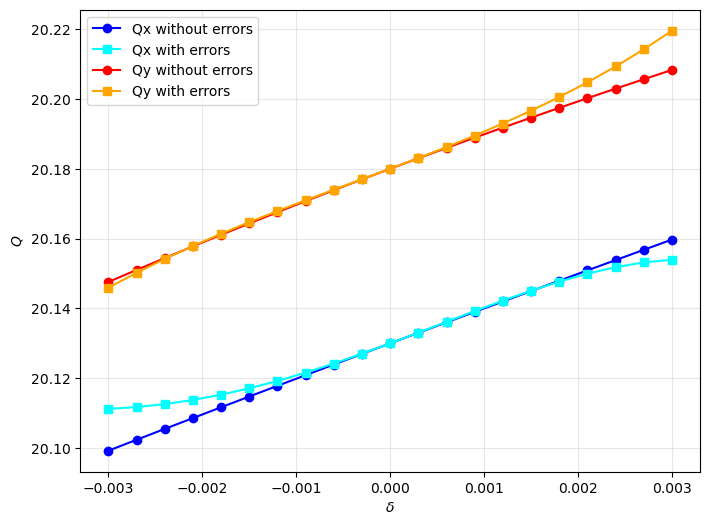

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(d_model3, qx_model3, 'o-', color='blue', label='Qx without errors')
ax.plot(d_model4, qx_model4, 's-', color='cyan', label='Qx with errors')
ax.plot(d_model3, qy_model3, 'o-', color='red', label='Qy without errors')
ax.plot(d_model4, qy_model4, 's-', color='orange', label='Qy with errors')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q$')
ax.grid(True, alpha=0.3)
ax.legend()
# plt.show()

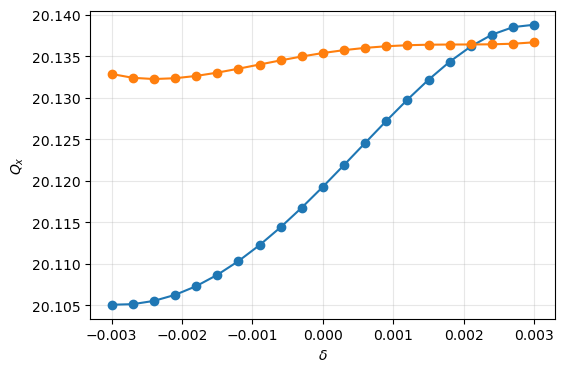

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_model4, qx_model4, 'o-', label='line with errors')
ax.plot(d_model5, qx_model5, 'o-', label='fitted line')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q_x$')
ax.grid(True, alpha=0.3)

In [63]:
qx0

np.float64(20.13535979106999)

In [141]:
line6 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env6 = line6.env
# env6.vars["qh_setvalue"] = 20.13
# env6.vars["qv_setvalue"] = 20.18

line6.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.173,       tol=1e-6, tag="tune"),
        ],
    )
env6.vars["qph_setvalue"] = 0.232
env6.vars["qpv_setvalue"] = -0.266
tw_bef = line6.twiss()
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env6.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

for nn in mba:
    env6[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env6[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env6[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env6[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line6.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx0*0.55, dqy=qy0*0.33, tol=1e-2, tag="chrom"),
        ],
    )
tw_aft = line6.twiss()
d_model6, qx_model6, qy_model6 = twiss_scan(line6, delta_grid4)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.1128                            
Matching: model call n. 6 penalty = 1.2292e-05              
Optimize - end penalty:  1.22921e-05                            
                                             
Optimize - start penalty: 1.025                             
Matching: model call n. 8 penalty = 3.9658e-04              
Optimize - end penalty:  0.000396577                            


In [142]:
tw_aft.qx, tw_aft.qy, tw_aft.dqx/tw_aft.qx, tw_aft.dqy/tw_aft.qy

(np.float64(20.135360006141433),
 np.float64(20.179123879348406),
 np.float64(0.5499900730979432),
 np.float64(0.3299830197330579))

In [143]:
env6.vars["qph_setvalue"]._value, env6.vars["qpv_setvalue"]._value

(np.float64(0.28240835321284574), np.float64(-0.2507874586388514))

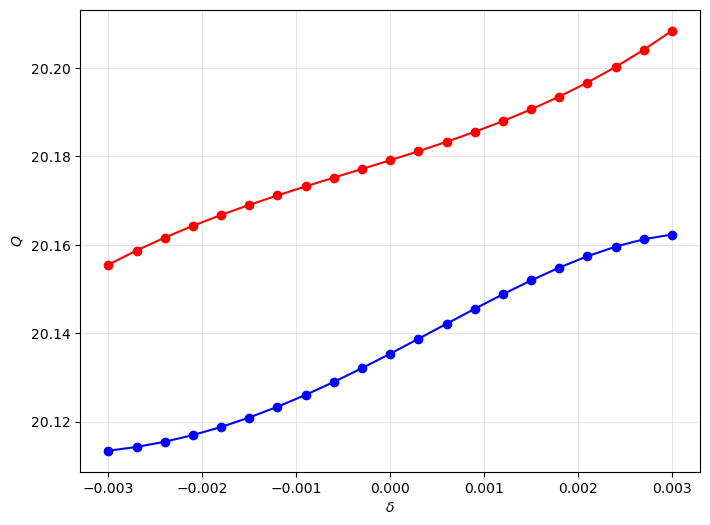

In [144]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(d_model6, qx_model6, 'o-', color='blue')
ax.plot(d_model6, qy_model6, 'o-', color='red')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q$')
ax.grid(True, alpha=0.3)

Text(0, 0.5, '$Q_y$')

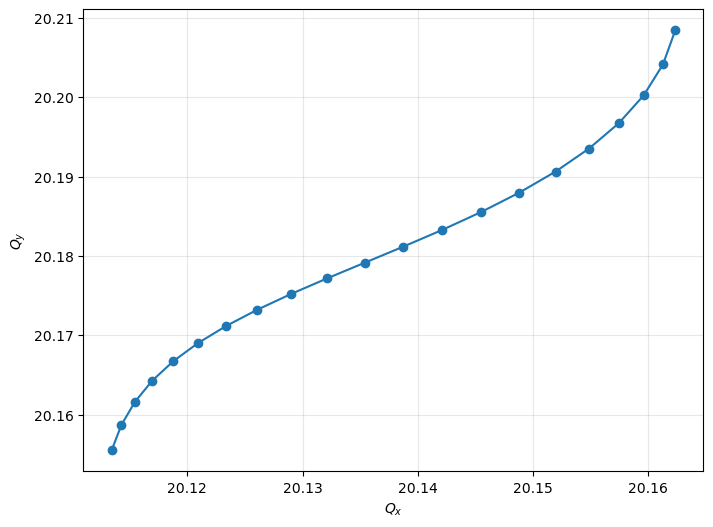

In [146]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(qx_model6, qy_model6, 'o-')
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$Q_x$')
ax.set_ylabel(r'$Q_y$')

In [147]:
delta_grid4

array([-0.003 , -0.0027, -0.0024, -0.0021, -0.0018, -0.0015, -0.0012,
       -0.0009, -0.0006, -0.0003,  0.    ,  0.0003,  0.0006,  0.0009,
        0.0012,  0.0015,  0.0018,  0.0021,  0.0024,  0.0027,  0.003 ])

In [148]:
np.linspace(-8e-3, 8e-3, 81)

array([-0.008 , -0.0078, -0.0076, -0.0074, -0.0072, -0.007 , -0.0068,
       -0.0066, -0.0064, -0.0062, -0.006 , -0.0058, -0.0056, -0.0054,
       -0.0052, -0.005 , -0.0048, -0.0046, -0.0044, -0.0042, -0.004 ,
       -0.0038, -0.0036, -0.0034, -0.0032, -0.003 , -0.0028, -0.0026,
       -0.0024, -0.0022, -0.002 , -0.0018, -0.0016, -0.0014, -0.0012,
       -0.001 , -0.0008, -0.0006, -0.0004, -0.0002,  0.    ,  0.0002,
        0.0004,  0.0006,  0.0008,  0.001 ,  0.0012,  0.0014,  0.0016,
        0.0018,  0.002 ,  0.0022,  0.0024,  0.0026,  0.0028,  0.003 ,
        0.0032,  0.0034,  0.0036,  0.0038,  0.004 ,  0.0042,  0.0044,
        0.0046,  0.0048,  0.005 ,  0.0052,  0.0054,  0.0056,  0.0058,
        0.006 ,  0.0062,  0.0064,  0.0066,  0.0068,  0.007 ,  0.0072,
        0.0074,  0.0076,  0.0078,  0.008 ])

In [156]:
d_model7, qx_model7, qy_model7 = twiss_scan(line6, np.linspace(-8e-3, 8e-3, 300))



Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




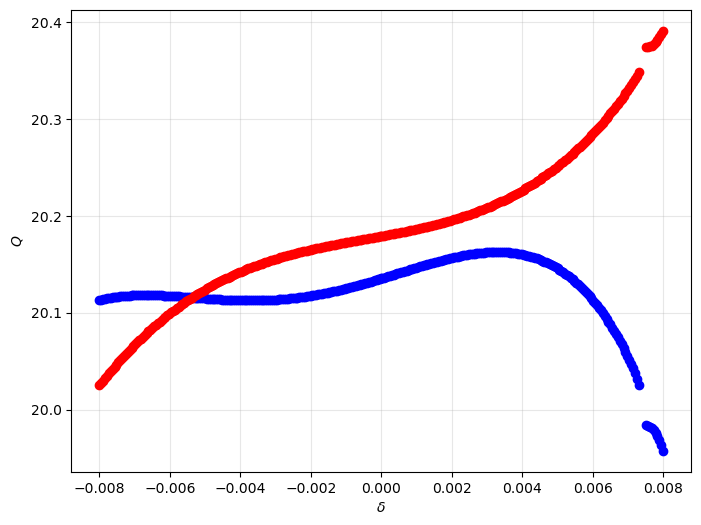

In [157]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(d_model7, qx_model7, 'o-', color='blue')
ax.plot(d_model7, qy_model7, 'o-', color='red')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q$')
ax.grid(True, alpha=0.3)

Text(0, 0.5, '$Q_y$')

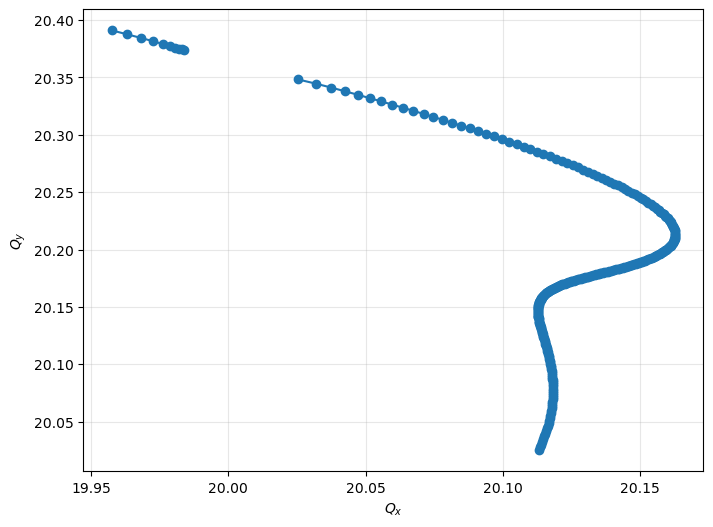

In [158]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(qx_model7, qy_model7, 'o-')
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$Q_x$')
ax.set_ylabel(r'$Q_y$')

In [90]:
env5 = line5.env
env5.vars["qph_setvalue"] = -0.267
env5.vars["qpv_setvalue"] = -0.582

d_model5, qx_model5, qy_model5 = twiss_scan(line5, delta_grid4)

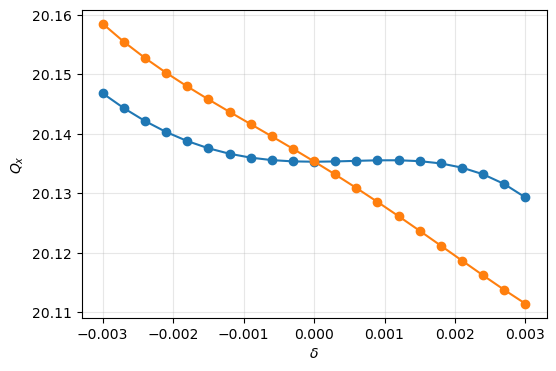

In [91]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_model6, qx_model6, 'o-', label='line with errors')
ax.plot(d_model5, qx_model5, 'o-', label='fitted line')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q_x$')
ax.grid(True, alpha=0.3)

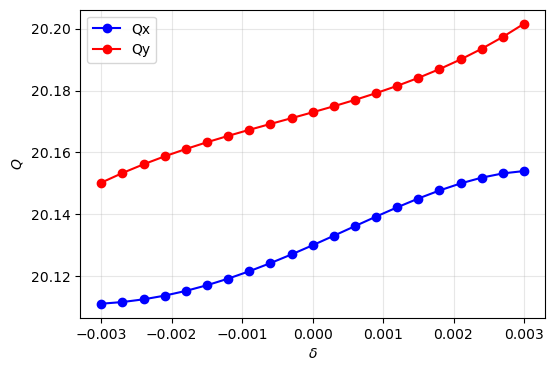

In [114]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_model6, qx_model6, 'o-', color='blue', label='Qx')
ax.plot(d_model6, qy_model6, 'o-', color='red', label='Qy')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$Q$')
ax.grid(True, alpha=0.3)
ax.legend()

In [115]:
print(tw_bef.qx, tw_bef.qy, tw_bef.dqx, tw_bef.dqy)
print(tw_aft.qx, tw_aft.qy, tw_aft.dqx, tw_aft.dqy)

20.129999591886993 20.173005519802636 4.68062994410967 -5.430368425709695
20.12996341338086 20.17296498802355 10.087013099896785 6.397395774521941


In [66]:
0.154*-0.001

-0.000154

In [67]:
20.135 + 0.154*-0.001

20.134846000000003

In [116]:
((qx_model6[11] - qx_model6[9]) / (delta_grid4[11] - delta_grid4[9]))/20.13

np.float64(0.4997196886567945)

In [87]:
delta_grid4[11] - delta_grid4[9]

np.float64(0.0006000000000000003)

In [117]:
((qy_model6[11] - qy_model6[9]) / (delta_grid4[11] - delta_grid4[9]))/qy0

np.float64(0.3181141374870516)

In [112]:
qx1/qx0

np.float64(0.06349935444522747)